# Day 2 —

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, re, joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import text_preprocessing as tp

df = pd.read_csv("Tweets.csv")[["airline_sentiment", "text"]].dropna().reset_index(drop=True)
train, test = train_test_split(df, test_size=0.2, stratify=df.airline_sentiment, random_state=42)
print(len(train), len(test))

11712 2928


## Task 1 — Baselines

In [2]:
cache = {m: (tp.preprocess_many(train.text, m), tp.preprocess_many(test.text, m)) for m in ["minimal", "lemma", "content"]}

def make(model, ngram):
    clf = LogisticRegression(C=3, max_iter=2000, class_weight="balanced") if model == "LR" \
          else LinearSVC(C=0.5, class_weight="balanced")
    return Pipeline([("tfidf", TfidfVectorizer(ngram_range=ngram, min_df=2, sublinear_tf=True)), ("clf", clf)])

rows = []
for mode, (Xtr, Xte) in cache.items():
    for model in ["LR", "SVM"]:
        for ngram in [(1, 1), (1, 2)]:
            p = make(model, ngram).fit(Xtr, train.airline_sentiment)
            pred = p.predict(Xte)
            rows.append(dict(preprocess=mode, model=model, ngram=ngram,
                             macro_f1=f1_score(test.airline_sentiment, pred, average="macro"),
                             acc=(pred == test.airline_sentiment).mean()))
res = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).round(4)
res

,preprocess,model,ngram,macro_f1,acc
5,lemma,LR,"(1, 2)",0.7607,0.8122
7,lemma,SVM,"(1, 2)",0.7598,0.8180
3,minimal,SVM,"(1, 2)",0.7482,0.8060
1,minimal,LR,"(1, 2)",0.7433,0.7951
9,content,LR,"(1, 2)",0.7383,0.7920
6,lemma,SVM,"(1, 1)",0.7366,0.7968
2,minimal,SVM,"(1, 1)",0.7346,0.7913
11,content,SVM,"(1, 2)",0.7327,0.7954
4,lemma,LR,"(1, 1)",0.7272,0.7794
0,minimal,LR,"(1, 1)",0.7260,0.7749


{'preprocess': 'lemma', 'model': 'LR', 'ngram': (1, 2), 'macro_f1': 0.7607, 'acc': 0.8122}
              precision    recall  f1-score   support

    negative      0.898     0.872     0.885      1835
     neutral      0.630     0.729     0.676       620
    positive      0.758     0.687     0.721       473

    accuracy                          0.812      2928
   macro avg      0.762     0.763     0.761      2928
weighted avg      0.819     0.812     0.814      2928



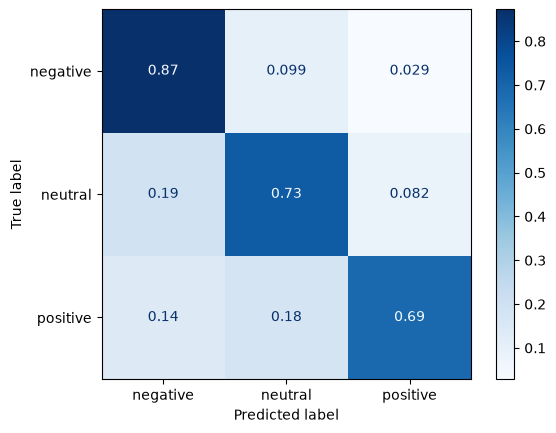

In [3]:
best = res.iloc[0]; print(best.to_dict())
Xtr, Xte = cache[best.preprocess]
pipe = make(best.model, best.ngram).fit(Xtr, train.airline_sentiment)
pred = pipe.predict(Xte)
print(classification_report(test.airline_sentiment, pred, digits=3))
ConfusionMatrixDisplay.from_predictions(test.airline_sentiment, pred, normalize="true", cmap="Blues")
plt.show()

In [4]:
# What did it learn?
vec, clf = pipe.named_steps["tfidf"], pipe.named_steps["clf"]
names = np.array(vec.get_feature_names_out())
for i, c in enumerate(clf.classes_):
    print(f"{c:9s}", ", ".join(names[np.argsort(clf.coef_[i])[-12:][::-1]]))

negative  not, delay, hour, no, bad, nothing, bag, again, your, lose, on hold, hold
neutral   can, be your, can you, xxuser any, xxurl, do you, or, xxuser be, xxuser when, hi, be flight, be there
positive  thank, great, awesome, love, good, amazing, appreciate, thx, the good, excellent, not wait, wonderful


In [5]:
joblib.dump({'pipeline': pipe, 'preprocess': best.preprocess}, 'baseline_tfidf.joblib')

['baseline_tfidf.joblib']

## Task 2 — Error analysis

In [6]:
te = test.copy()
te["pred"] = pred
margin = pipe.decision_function(Xte)
te["margin"] = np.sort(margin, axis=1)[:, -1] - np.sort(margin, axis=1)[:, -2]   # confidence gap top1-top2
errs = te[te.pred != te.airline_sentiment].copy()
print(f"{len(errs)} errors / {len(te)} ({len(errs)/len(te):.1%})")
print(errs.groupby(["airline_sentiment", "pred"]).size().sort_values(ascending=False))

550 errors / 2928 (18.8%)
airline_sentiment  pred    
negative           neutral     181
neutral            negative    117
positive           neutral      84
                   negative     64
negative           positive     53
neutral            positive     51
dtype: int64


In [7]:
NEG = re.compile(r"\b(not|no|never|n't|nothing|without|cannot|can't|won't|didn't|wasn't|don't)\b", re.I)
CONTRAST = re.compile(r"\b(but|however|though|although|yet)\b", re.I)
POS_WORDS = re.compile(r"\b(thanks?|thx|great|love|awesome|amazing|perfect|best|nice|wonderful|fantastic)\b", re.I)

def hint(r):
    t, n = r.text, len(re.sub(r"@\w+|https?://\S+", "", r.text).split())
    if r.airline_sentiment == "negative" and POS_WORDS.search(t) and r.pred == "positive": return "sarcasm/irony?"
    if NEG.search(t):        return "negation?"
    if CONTRAST.search(t):   return "mixed sentiment?"
    if n <= 5:               return "short text?"
    if r.airline_sentiment == "neutral" or r.pred == "neutral": return "ambiguous neutral?"
    return "other?"

errs["hint"] = errs.apply(hint, axis=1)
print(errs.hint.value_counts())

hint
ambiguous neutral?    270
negation?             101
short text?            65
other?                 49
mixed sentiment?       41
sarcasm/irony?         24
Name: count, dtype: int64


In [ ]:

pd.set_option("display.max_colwidth", 200)
sample = pd.concat([errs.sample(5, random_state=1), errs.nlargest(5, "margin")]).drop_duplicates().head(10)
sample[["text", "airline_sentiment", "pred", "margin", "hint"]]

,text,airline_sentiment,pred,margin,hint
4266,"@united I normally ask people to put on headphones...but not toddlers. Maybe planes should have a ""kid"" section (near the back) ;)",neutral,negative,1.302804,negation?
1588,@united I did. they told us the wrong carousel number.,neutral,negative,1.066365,ambiguous neutral?
8186,@JetBlue that is great. But once it gets to Buffalo will it be able to leave and get to JFK? Or there's issues still at Buffalo airport?,positive,negative,0.346951,mixed sentiment?
6813,@JetBlue Thank you for credits. However; I submitted complaints about the property on vacation package. Hope you listen!,negative,positive,1.043509,sarcasm/irony?
13384,@AmericanAir thanks hoping that by wed I can get back to DFW,positive,neutral,2.023237,ambiguous neutral?
9585,@USAirways I will. Is it down or is just me?,negative,neutral,4.553050,ambiguous neutral?
5873,@SouthwestAir me &amp; @sammi_jon3s are best friends because of @Imaginedragons. Any chance we could get tickets to #DestinationDragons ?,positive,neutral,4.454590,ambiguous neutral?
13022,"@AmericanAir Considering it was past midnight, I hung up and called again to receive another service call.",neutral,negative,4.007005,ambiguous neutral?
6497,@SouthwestAir thanks for taking such good care of my luggage... http://t.co/PIvxean3jY,negative,positive,3.928844,sarcasm/irony?
8824,@JetBlue's CEO battles to appease passengers and Wall Street - http://t.co/uy28D1UEgX http://t.co/vJFV7KSGcQ,positive,neutral,3.877302,ambiguous neutral?


In [15]:
sample = sample.assign(
    category=[
        "label ambiguity",      # 4266
        "label ambiguity",      # 1588
        "mixed sentiment",      # 8186
        "mixed sentiment",      # 6813
        "implicit / weak sentiment",  # 13384
        "label noise",          # 9585
        "implicit / weak sentiment",  # 5873
        "label noise",          # 13022
        "sarcasm",              # 6497
        "label noise",          # 8824
    ],
    why=[
        "'not' is about toddlers, not sentiment; a mild opinion labeled neutral",
        "describes a problem (wrong carousel) but no emotion; neutral vs negative is arguable",
        "'that is great. But...' positive then a worry; model latched onto the worry",
        "'Thank you... However; I submitted complaints'; polite thanks + complaint, not sarcasm",
        "'thanks' plus a hope; weak signal, no strong words",
        "'Is it down or is just me?' is a plain question; negative label looks wrong (confident neutral)",
        "positivity is implicit (best friends, asking for tickets); no sentiment words the model knows",
        "recounts a bad experience but labeled neutral; the label is questionable",
        "'thanks for taking such good care of my luggage...' is real sarcasm; the model saw 'thanks/good care'",
        "a news headline with links labeled positive; label looks wrong",
    ],
)
sample[["text", "airline_sentiment", "pred", "category", "why"]]

,text,airline_sentiment,pred,category,why
4266,"@united I normally ask people to put on headphones...but not toddlers. Maybe planes should have a ""kid"" section (near the back) ;)",neutral,negative,label ambiguity,"'not' is about toddlers, not sentiment; a mild opinion labeled neutral"
1588,@united I did. they told us the wrong carousel number.,neutral,negative,label ambiguity,describes a problem (wrong carousel) but no emotion; neutral vs negative is arguable
8186,@JetBlue that is great. But once it gets to Buffalo will it be able to leave and get to JFK? Or there's issues still at Buffalo airport?,positive,negative,mixed sentiment,'that is great. But...' positive then a worry; model latched onto the worry
6813,@JetBlue Thank you for credits. However; I submitted complaints about the property on vacation package. Hope you listen!,negative,positive,mixed sentiment,"'Thank you... However; I submitted complaints'; polite thanks + complaint, not sarcasm"
13384,@AmericanAir thanks hoping that by wed I can get back to DFW,positive,neutral,implicit / weak sentiment,"'thanks' plus a hope; weak signal, no strong words"
9585,@USAirways I will. Is it down or is just me?,negative,neutral,label noise,'Is it down or is just me?' is a plain question; negative label looks wrong (confident neutral)
5873,@SouthwestAir me &amp; @sammi_jon3s are best friends because of @Imaginedragons. Any chance we could get tickets to #DestinationDragons ?,positive,neutral,implicit / weak sentiment,"positivity is implicit (best friends, asking for tickets); no sentiment words the model knows"
13022,"@AmericanAir Considering it was past midnight, I hung up and called again to receive another service call.",neutral,negative,label noise,recounts a bad experience but labeled neutral; the label is questionable
6497,@SouthwestAir thanks for taking such good care of my luggage... http://t.co/PIvxean3jY,negative,positive,sarcasm,'thanks for taking such good care of my luggage...' is real sarcasm; the model saw 'thanks/good care'
8824,@JetBlue's CEO battles to appease passengers and Wall Street - http://t.co/uy28D1UEgX http://t.co/vJFV7KSGcQ,positive,neutral,label noise,a news headline with links labeled positive; label looks wrong


In [ ]:

te["n_words"] = te.text.str.replace(r"@\w+|https?://\S+", "", regex=True).str.split().str.len()
te["err"] = te.pred != te.airline_sentiment
te.groupby(pd.cut(te.n_words, [0, 5, 10, 15, 20, 40]), observed=True).err.agg(["mean", "size"]).round(3)

,mean,size
n_words,,
"(0, 5]",0.291,254
"(5, 10]",0.226,425
"(10, 15]",0.213,521
"(15, 20]",0.182,696
"(20, 40]",0.138,1032


### Summary of failure types (10 misclassified examples)

| Failure type | Count | Example | Fix to try |
|---|---|---|---|
| Label noise / ambiguity | 5 | "@USAirways I will. Is it down or is just me?" (true: negative, predicted: neutral) | Filter with `airline_sentiment_confidence`; relabel or merge neutral |
| Mixed sentiment | 2 | "Thank you for credits. However; I submitted complaints..." (true: negative, predicted: positive) | Split by sentence or clause; aspect-based sentiment |
| Implicit / weak sentiment | 2 | "...best friends because of @Imaginedragons. Any chance we could get tickets...?" (true: positive, predicted: neutral) | Pretrained transformer (DistilBERT); char n-grams |
| Sarcasm | 1 | "thanks for taking such good care of my luggage..." (true: negative, predicted: positive) | A transformer with more context; punctuation and emoji features |
| Negation | 0 | None in this sample; the auto-hint flagged one, but it was a false alarm | Bigrams already help; try `NOT_` marking |

*This is a sample of only 10 errors out of about 550, so the proportions are illustrative, not exact.*

**Key takeaways**
- TF-IDF (lemma, unigrams + bigrams) with Logistic Regression is a strong baseline: macro-F1 0.761, accuracy 0.812.
- Neutral is the weakest class (F1 0.676), then positive (0.721). Negative is strongest (0.885).
- Half of the sampled errors involve questionable labels, so part of the ceiling comes from the data, not the model. Only 1 of 10 was true sarcasm.
